<a href="https://colab.research.google.com/github/DarvusLau919/titanic-eda-beginner/blob/main/titanic-eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [5]:
import pandas as pd
df = pd.read_csv('train.csv')

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

In [7]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Missing values
print(df.isnull().sum())

# Cleaning
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1)

print("\nAfter cleaning:")
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

After cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [9]:
print("Overall Survival Rate:", round(df['Survived'].mean()*100, 2), "%")

print("\nSurvival by Gender:")
print(df.groupby('Sex')['Survived'].mean())

print("\nSurvival by Class:")
print(df.groupby('Pclass')['Survived'].mean())

Overall Survival Rate: 38.38 %

Survival by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


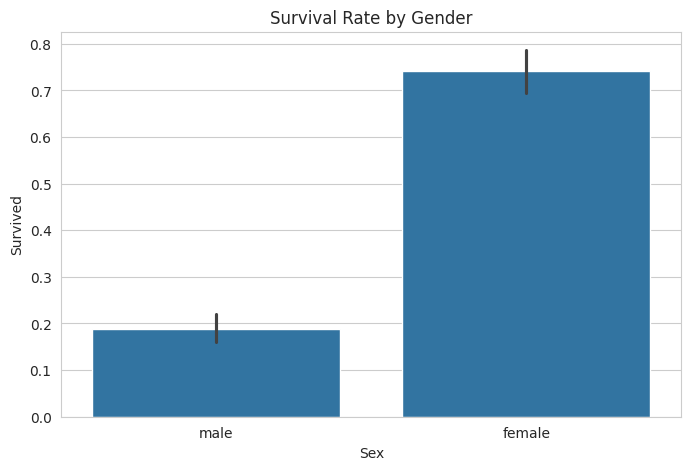

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

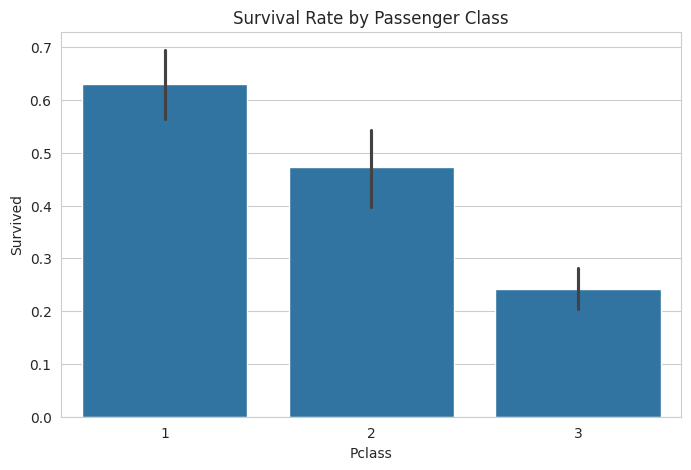

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

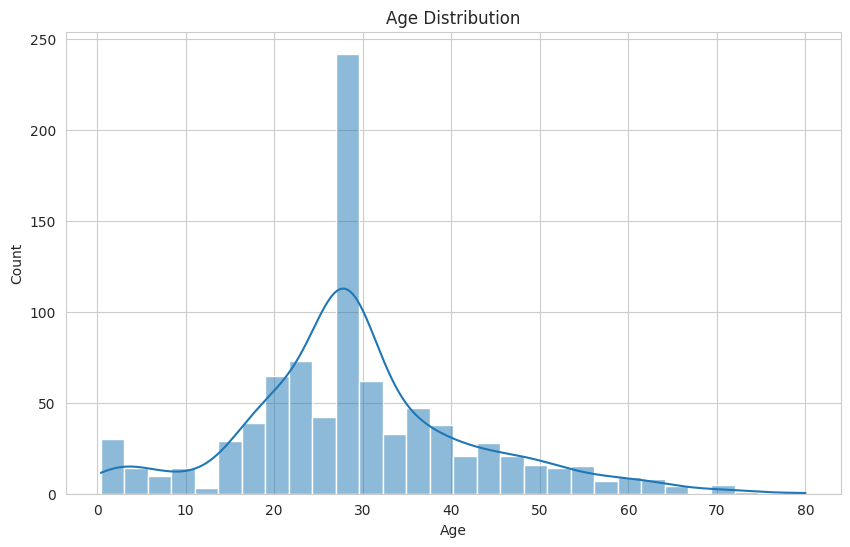

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

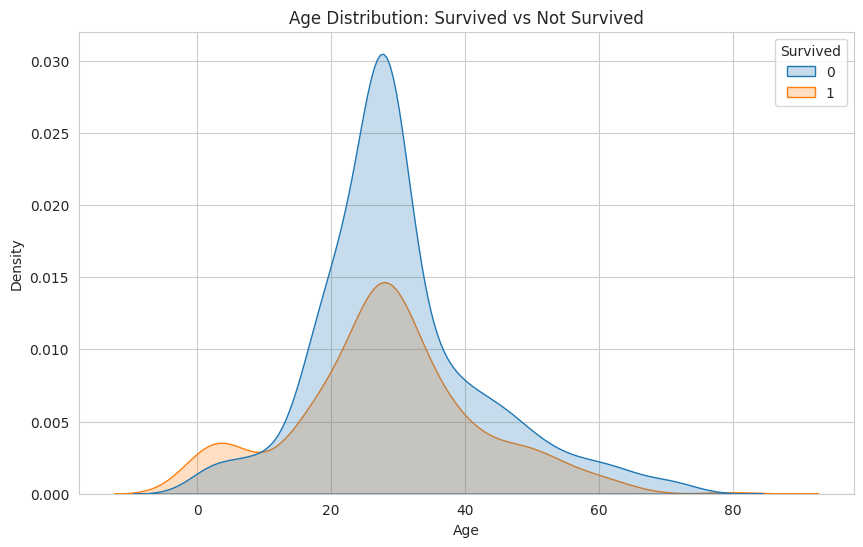

In [13]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True)
plt.title('Age Distribution: Survived vs Not Survived')
plt.show()

# Titanic Dataset Exploratory Data Analysis

## Objective
Analyze factors that affected survival on the Titanic using exploratory data analysis (EDA). The goal is to identify key patterns and insights that explain why some passengers were more likely to survive than others.

## Dataset Overview
- **Source**: Kaggle Titanic Dataset
- **Rows**: 891 passengers
- **Columns**: 12 features including Age, Sex, Passenger Class, Fare, etc.
- **Target Variable**: `Survived` (0 = Did not survive, 1 = Survived)

## Tools Used
- Python
- Pandas (data manipulation)
- Matplotlib & Seaborn (visualization)
- Google Colab (development environment)

## Data Cleaning Steps
- Filled missing `Age` values with the median age
- Filled missing `Embarked` values with the most common port
- Dropped the `Cabin` column (too many missing values)

## Exploratory Analysis & Key Insights

### 1. Overall Survival Rate
- Only **38.38%** of passengers survived the disaster.

### 2. Gender vs Survival
- **Female** survival rate: ~74.0%
- **Male** survival rate: ~18.9%
- **Insight**: Women were significantly more likely to survive (likely due to "women and children first" policy).

### 3. Passenger Class vs Survival
- 1st Class survival rate: **62.96%**
- 2nd Class survival rate: **47.28%**
- 3rd Class survival rate: **24.24%**
- **Insight**: Higher socio-economic status (1st class) had a clear survival advantage.

### 4. Age Distribution
- Younger passengers (especially children) had better survival chances.
- The majority of passengers were between 20–40 years old.

### 5. Other Observations
- Passengers who embarked from **Cherbourg** had a higher survival rate.
- Higher fare (which correlates with class) was associated with better survival odds.

## Visualizations

*(Insert your charts here in Colab — they will appear below this section)*

- Survival Rate by Gender
- Survival Rate by Passenger Class
- Age Distribution of Passengers
- Age Distribution: Survived vs Not Survived

## Conclusion & Learnings
The strongest predictors of survival were:
1. **Sex** (Female >> Male)
2. **Passenger Class** (1st > 2nd > 3rd)
3. **Age** (Children had priority)

This analysis demonstrates how basic data exploration using Python can reveal meaningful business/human insights from historical data.

## Future Improvements
- Feature engineering (create "Family Size", "Title from Name", etc.)
- Build a simple predictive model (Logistic Regression)
- Create an interactive dashboard using Plotly or Streamlit